# **Taller 5**

* Nicolas Rozo Fajardo - 202112920
* Santiago Martínez Novoa - 202112020

# **1. Filtros lineales suavizantes**

In [18]:
from skimage.morphology import footprint_rectangle
from skimage.filters.rank import mean
from scipy.signal import convolve
import matplotlib.pyplot as plt
import numpy as np
import cv2

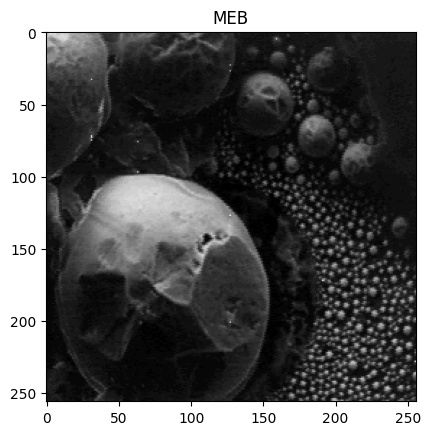

In [3]:
meb_image = cv2.imread("../images/meb.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(meb_image, cmap = "gray", vmin = 0, vmax = 255)
plt.title("MEB")

plt.show()

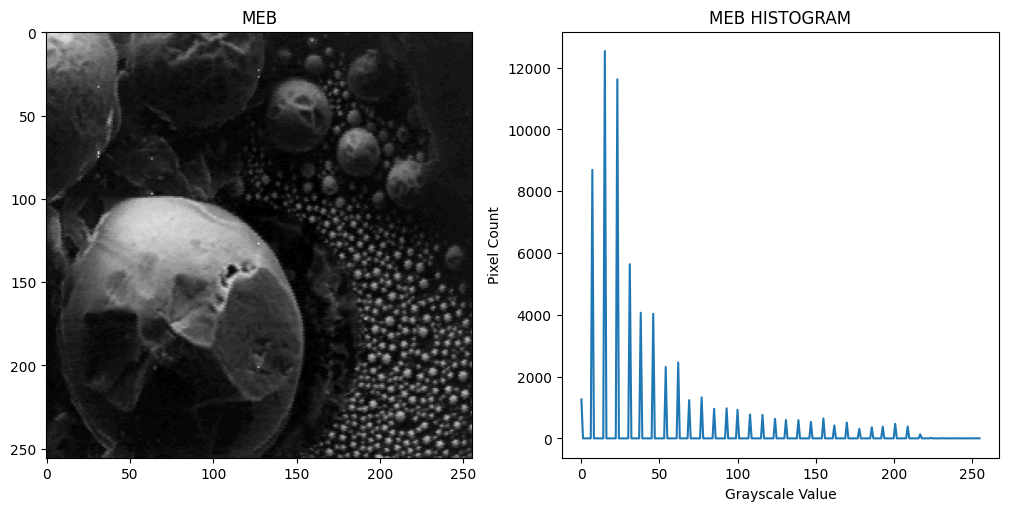

In [4]:
hist_meb = cv2.calcHist([meb_image], [0], None, [256], [0, 256])

fig, ax = plt.subplots(1, 2, layout = "constrained", figsize = (10, 5))

ax[0].imshow(meb_image, cmap = "gray", vmin = 0, vmax = 255)
ax[0].set_title("MEB")

ax[1].plot(hist_meb)
ax[1].set_title("MEB HISTOGRAM")
ax[1].set_xlabel("Grayscale Value")
ax[1].set_ylabel("Pixel Count")

plt.show()

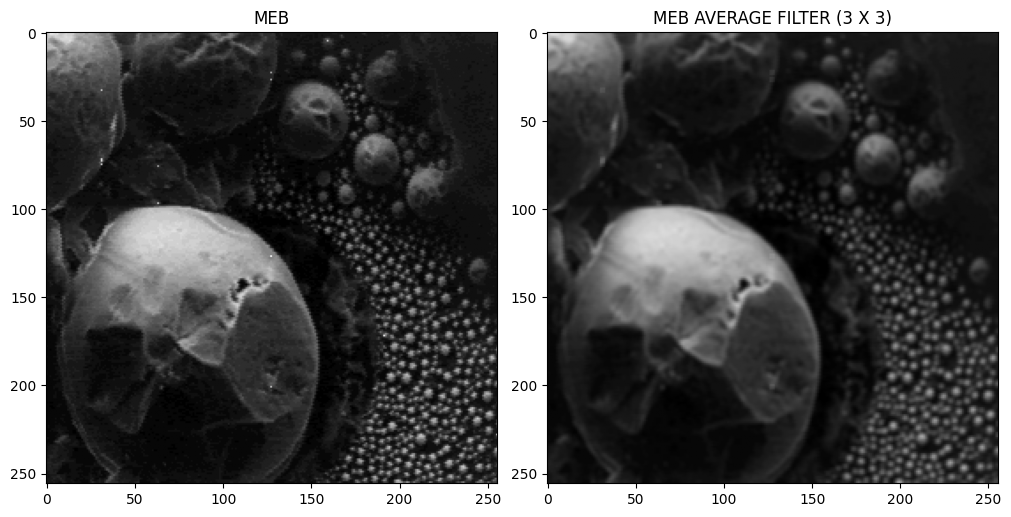

In [ ]:
avg_meb = mean(meb_image, footprint_rectangle((3, 3)))

fig, ax = plt.subplots(1, 2, layout = "constrained", figsize = (10, 5))

ax[0].imshow(meb_image, cmap = "gray", vmin = 0, vmax = 255)
ax[0].set_title("MEB")

ax[1].imshow(avg_meb, cmap = "gray", vmin = 0, vmax = 255)
ax[1].set_title("MEB AVERAGE FILTER (3 X 3)")
plt.show()

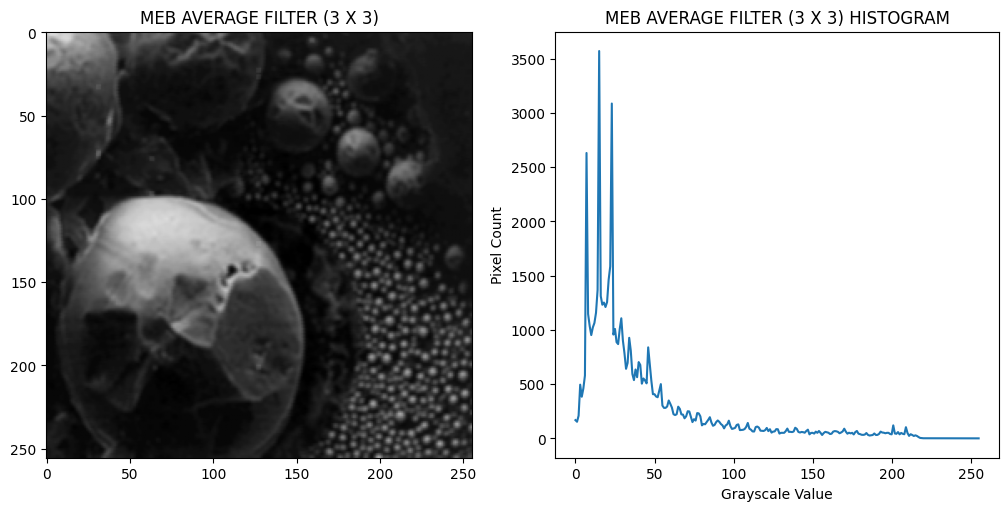

In [8]:
hist_avg_meb = cv2.calcHist([avg_meb], [0], None, [256], [0, 256])

fig, ax = plt.subplots(1, 2, layout = "constrained", figsize = (10, 5))

ax[0].imshow(avg_meb, cmap = "gray", vmin = 0, vmax = 255)
ax[0].set_title("MEB AVERAGE FILTER (3 X 3)")

ax[1].plot(hist_avg_meb)
ax[1].set_title("MEB AVERAGE FILTER (3 X 3) HISTOGRAM")
ax[1].set_xlabel("Grayscale Value")
ax[1].set_ylabel("Pixel Count")

plt.show()

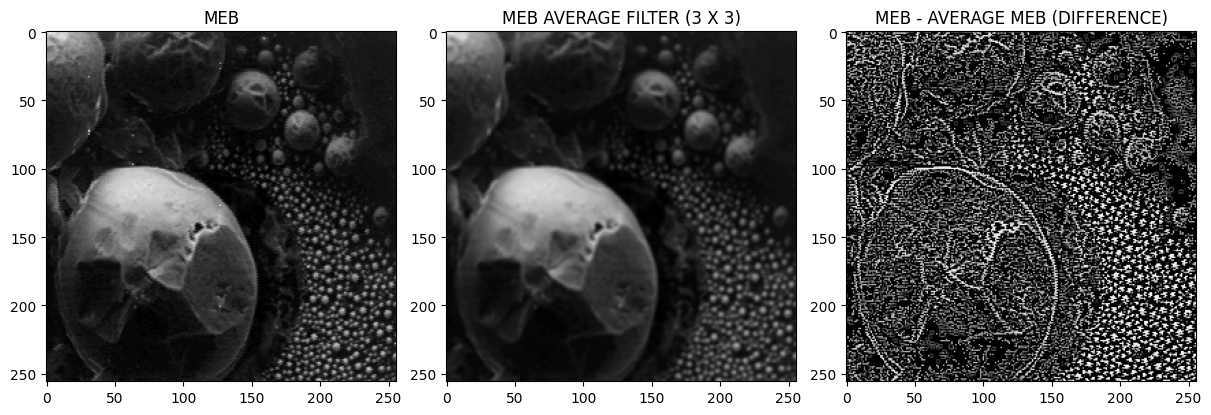

In [13]:
difference_meb = cv2.subtract(meb_image, avg_meb)

fig, ax = plt.subplots(1, 3, layout = "constrained", figsize = (12, 10))

ax[0].imshow(meb_image, cmap = "gray", vmin = 0, vmax = 255)
ax[0].set_title("MEB")

ax[1].imshow(avg_meb, cmap = "gray", vmin = 0, vmax = 255)
ax[1].set_title("MEB AVERAGE FILTER (3 X 3)")

ax[2].imshow(cv2.equalizeHist(difference_meb) , cmap = "gray", vmin = 0, vmax = 255)
ax[2].set_title("MEB - AVERAGE MEB (DIFFERENCE)")

plt.show()


In [14]:
avg_meb_5 = mean(meb_image, footprint_rectangle((5, 5)))

hist_avg_meb_5 = cv2.calcHist([avg_meb_5], [0], None, [256], [0, 256])

In [15]:
avg_meb_3 = mean(meb_image, footprint_rectangle((3, 3)))
avg_meb_3 = mean(avg_meb_3, footprint_rectangle((3, 3)))

hist_avg_meb_3 = cv2.calcHist([avg_meb_3], [0], None, [256], [0, 256])

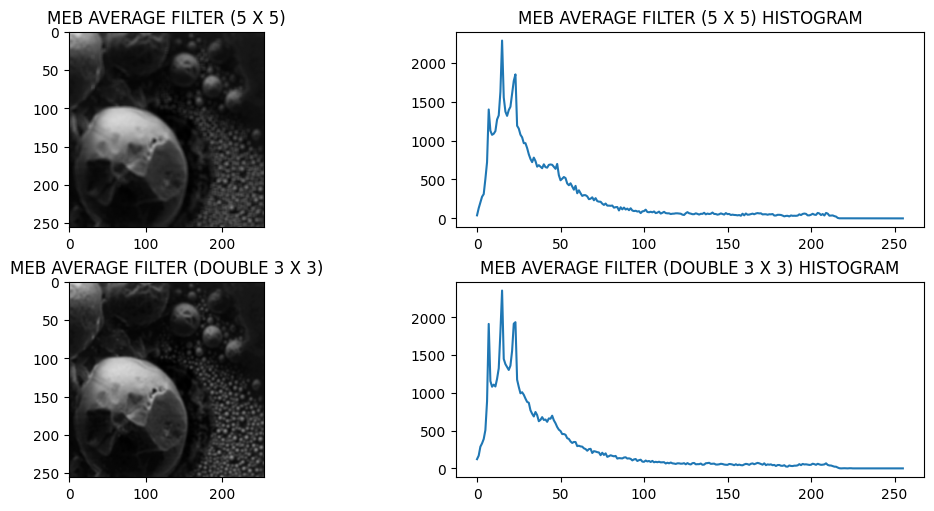

In [16]:
fig, ax = plt.subplots(2, 2, layout = "constrained", figsize = (10, 5))

ax[0, 0].imshow(avg_meb_5, cmap = "gray", vmin = 0, vmax = 255)
ax[0, 0].set_title("MEB AVERAGE FILTER (5 X 5)")

ax[0, 1].plot(hist_avg_meb_5)
ax[0, 1].set_title("MEB AVERAGE FILTER (5 X 5) HISTOGRAM")

ax[1, 0].imshow(avg_meb_3, cmap = "gray", vmin = 0, vmax = 255)
ax[1, 0].set_title("MEB AVERAGE FILTER (DOUBLE 3 X 3)")

ax[1, 1].plot(hist_avg_meb_3)
ax[1, 1].set_title("MEB AVERAGE FILTER (DOUBLE 3 X 3) HISTOGRAM")

plt.show()


In [20]:
average_3 = np.full((3, 3), 1/9)
print("\n===== AVERAGE 3 X 3 KERNEL =====\n")
print(average_3)

average_5 = np.full((5, 5), 1/25)
print("\n===== AVERAGE 5 X 5 KERNEL =====\n")
print(average_5)

double_convolve = convolve(average_3, average_3)
print("\n===== DOUBLE AVERAGE 3 X 3 KERNEL =====\n")
print(double_convolve)


===== AVERAGE 3 X 3 KERNEL =====

[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]

===== AVERAGE 5 X 5 KERNEL =====

[[0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]]

===== DOUBLE AVERAGE 3 X 3 KERNEL =====

[[0.01234568 0.02469136 0.03703704 0.02469136 0.01234568]
 [0.02469136 0.04938272 0.07407407 0.04938272 0.02469136]
 [0.03703704 0.07407407 0.11111111 0.07407407 0.03703704]
 [0.02469136 0.04938272 0.07407407 0.04938272 0.02469136]
 [0.01234568 0.02469136 0.03703704 0.02469136 0.01234568]]


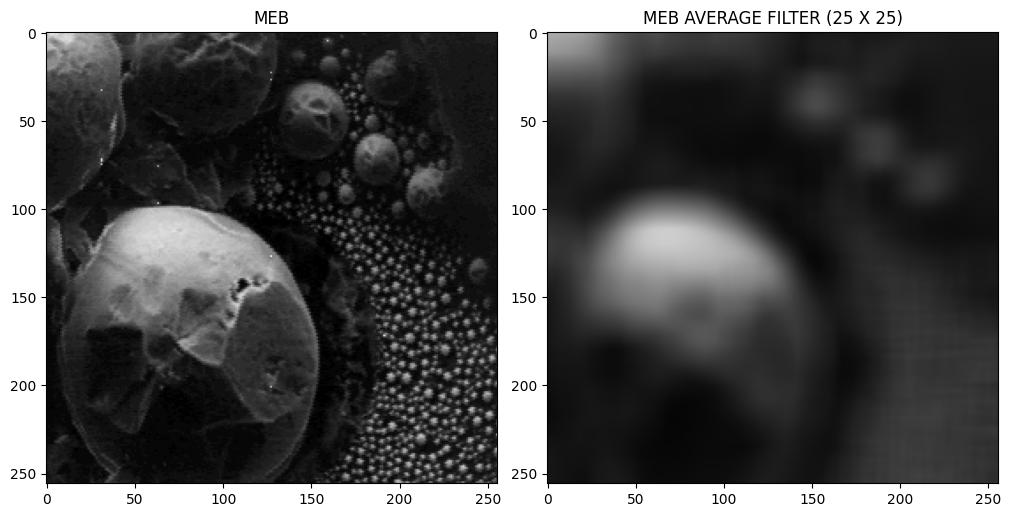

In [21]:
avg_meb_25 = mean(meb_image, footprint_rectangle((25, 25)))

fig, ax = plt.subplots(1, 2, layout = "constrained", figsize = (10, 5))

ax[0].imshow(meb_image, cmap = "gray", vmin = 0, vmax = 255)
ax[0].set_title("MEB")

ax[1].imshow(avg_meb_25, cmap = "gray", vmin = 0, vmax = 255)
ax[1].set_title("MEB AVERAGE FILTER (25 X 25)")

plt.show()

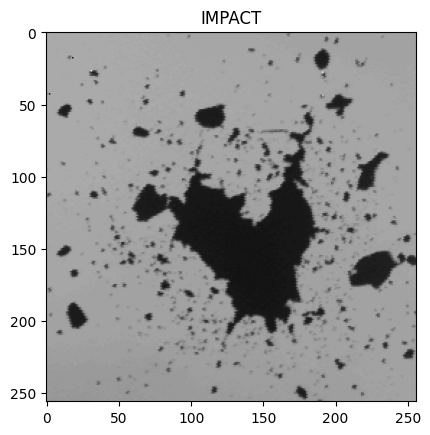

In [23]:
impact_image = cv2.imread("../images/impact.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(impact_image, cmap = "gray", vmin = 0, vmax = 255)
plt.title("IMPACT")

plt.show()

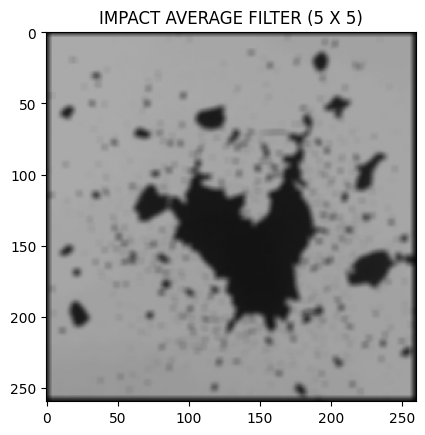

In [24]:
avg_kernel_5 = np.full((5, 5), 1/25)

avg_impact_5 = convolve(impact_image, avg_kernel_5)

plt.imshow(avg_impact_5, cmap = "gray", vmin = 0, vmax = 255)
plt.title("IMPACT AVERAGE FILTER (5 X 5)")

plt.show()

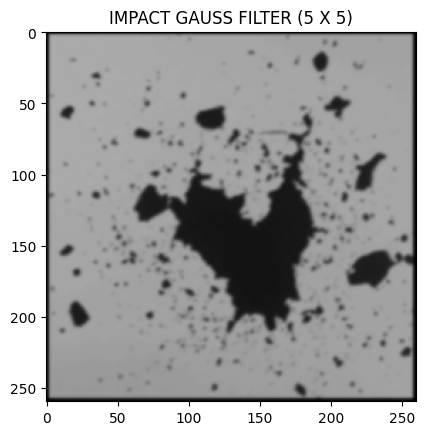

In [25]:
gauss_kernel_5 = cv2.getGaussianKernel(5, 1) @ cv2.getGaussianKernel(5, 1).T

gauss_impact_5 = convolve(impact_image, gauss_kernel_5)

plt.imshow(gauss_impact_5, cmap = "gray", vmin = 0, vmax = 255)
plt.title("IMPACT GAUSS FILTER (5 X 5)")

plt.show()

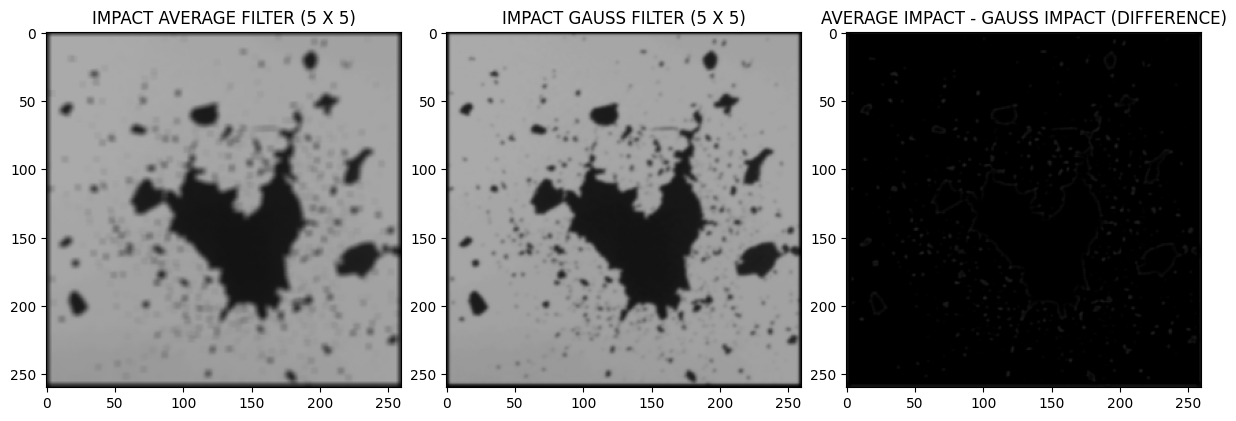

In [27]:
difference_impact = cv2.subtract(avg_impact_5, gauss_impact_5)

fig, ax = plt.subplots(1, 3, layout = "constrained", figsize = (12, 10))

ax[0].imshow(avg_impact_5, cmap = "gray", vmin = 0, vmax = 255)
ax[0].set_title("IMPACT AVERAGE FILTER (5 X 5)")

ax[1].imshow(gauss_impact_5, cmap = "gray", vmin = 0, vmax = 255)
ax[1].set_title("IMPACT GAUSS FILTER (5 X 5)")

ax[2].imshow(difference_impact , cmap = "gray", vmin = 0, vmax = 255)
ax[2].set_title("AVERAGE IMPACT - GAUSS IMPACT (DIFFERENCE)")

plt.show()


# **2. Filtro lineales separables**

In [30]:
import time

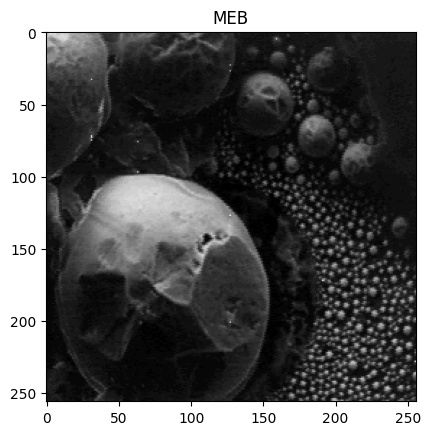

In [28]:
meb_image = cv2.imread("../images/meb.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(meb_image, cmap = "gray", vmin = 0, vmax = 255)
plt.title("MEB")

plt.show()

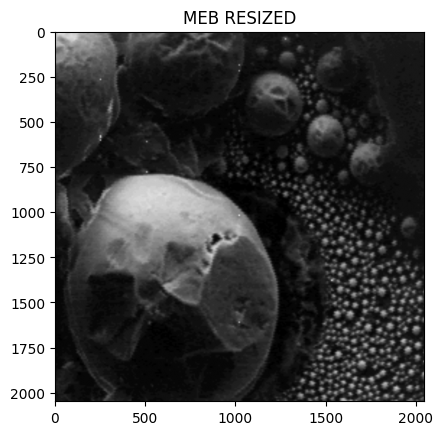

In [29]:
meb_resized_image = cv2.resize(meb_image, (2048, 2048))

plt.imshow(meb_resized_image, cmap = "gray", vmin = 0, vmax = 255)
plt.title("MEB RESIZED")

plt.show()

In [42]:
run_times_3_3 = []

avg_kernel_3_3 = np.full((3, 3), 1/9)

for i in range(30):

  start_time = time.time()
  result_traditional = convolve(meb_resized_image, avg_kernel_3_3)
  end_time = time.time()

  run_times_3_3.append(end_time - start_time)

print("\nTIMES - 3 X 3 AVERAGE FILTER (CONVOLUTION)\n")
print(run_times_3_3)


TIMES - 3 X 3 AVERAGE FILTER (CONVOLUTION)

[0.07323360443115234, 0.06343436241149902, 0.06393313407897949, 0.06392264366149902, 0.06461763381958008, 0.06453442573547363, 0.06515026092529297, 0.06404781341552734, 0.06502079963684082, 0.06536507606506348, 0.0652608871459961, 0.06435322761535645, 0.06431937217712402, 0.06436562538146973, 0.0660240650177002, 0.06884551048278809, 0.0655522346496582, 0.0645902156829834, 0.07005763053894043, 0.07289409637451172, 0.06492304801940918, 0.06514334678649902, 0.06425881385803223, 0.0636131763458252, 0.06478643417358398, 0.06479763984680176, 0.0641031265258789, 0.0643155574798584, 0.06490254402160645, 0.06559419631958008]


In [43]:
run_times_sep = []

avg_kernel_3_1 = np.full((3, 1), 1/3)
avg_kernel_1_3 = np.full((1, 3), 1/3)

for i in range(30):

    start_time = time.time()
    temp = convolve(meb_resized_image, avg_kernel_3_1)
    result_separable = convolve(temp, avg_kernel_1_3)
    end_time = time.time()
    run_times_sep.append(end_time - start_time)

print("\nTIMES - 3 X 1 + 1 X 3 AVERAGE FILTER (SEPARABLE)\n")
print(run_times_sep)


TIMES - 3 X 1 + 1 X 3 AVERAGE FILTER (SEPARABLE)

[0.26317882537841797, 0.2548351287841797, 0.2598154544830322, 0.2613959312438965, 0.2664501667022705, 0.2453446388244629, 0.2551157474517822, 0.25612568855285645, 0.2568228244781494, 0.2574772834777832, 0.2564046382904053, 0.2642688751220703, 0.256267786026001, 0.25620412826538086, 0.2501809597015381, 0.2534370422363281, 0.2535665035247803, 0.250762939453125, 0.2518348693847656, 0.2604823112487793, 0.26056480407714844, 0.2606372833251953, 0.2549111843109131, 0.2626316547393799, 0.26262760162353516, 0.2636144161224365, 0.2492353916168213, 0.2597920894622803, 0.25505828857421875, 0.2542836666107178]


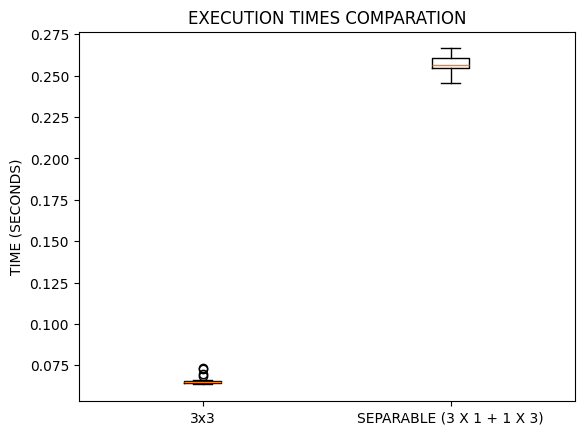

AVERAGE 3 X 3: 0.0655320167541504
AVERAGE 3 X 1 + 1 X 3: 0.2571109374364217


In [44]:
plt.figure()

plt.boxplot([run_times_3_3, run_times_sep])
plt.xticks([1, 2], ["3x3", "SEPARABLE (3 X 1 + 1 X 3)"])
plt.ylabel("TIME (SECONDS)")
plt.title("EXECUTION TIMES COMPARATION")
plt.show()

print("AVERAGE 3 X 3:", np.mean(run_times_3_3))
print("AVERAGE 3 X 1 + 1 X 3:", np.mean(run_times_sep))

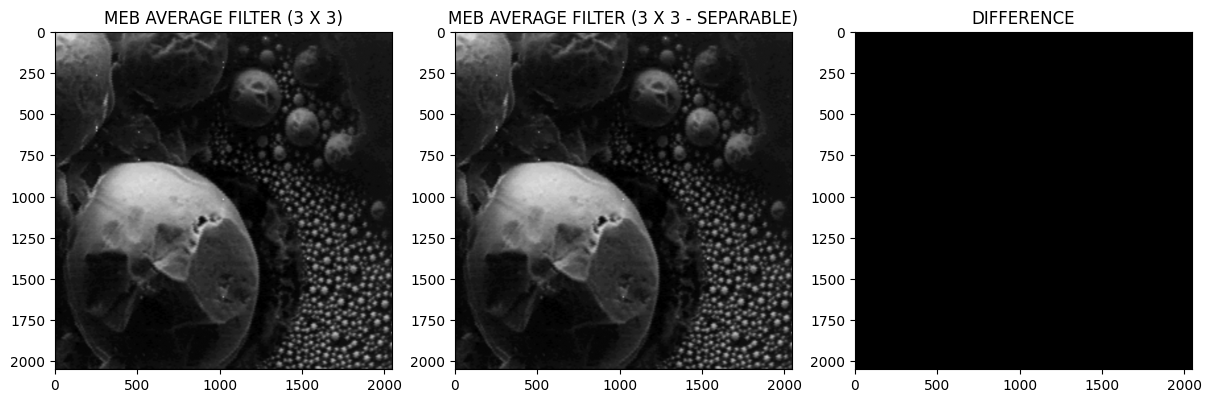

In [46]:
difference_meb = cv2.subtract(result_separable, result_traditional)

fig, ax = plt.subplots(1, 3, layout = "constrained", figsize = (12, 10))

ax[0].imshow(result_traditional, cmap = "gray", vmin = 0, vmax = 255)
ax[0].set_title("MEB AVERAGE FILTER (3 X 3)")

ax[1].imshow(result_separable, cmap = "gray", vmin = 0, vmax = 255)
ax[1].set_title("MEB AVERAGE FILTER (3 X 3 - SEPARABLE)")

ax[2].imshow(difference_meb , cmap = "gray", vmin = 0, vmax = 255)
ax[2].set_title("DIFFERENCE")

plt.show()


In [ ]:
run_times_30_30 = []

avg_kernel_30_30 = np.full((30, 30), 1/(30 * 30))

for i in range(30):

    start_time = time.time()
    result_30 = convolve(meb_resized_image, avg_kernel_30_30)
    end_time = time.time()
    run_times_30_30.append(end_time - start_time)

print("\nTIMES - 30 X 30 AVERAGE FILTER (CONVOLUTION)\n")
print(run_times_30_30)


TIMES - 30 X 30 AVERAGE FILTER (CONVOLUTION)

[0.0763850212097168, 0.06601405143737793, 0.06681394577026367, 0.06675171852111816, 0.0740048885345459, 0.07187342643737793, 0.08154559135437012, 0.06786751747131348, 0.06713271141052246, 0.0663752555847168, 0.0668177604675293, 0.0648355484008789, 0.0669407844543457, 0.06650853157043457, 0.0677638053894043, 0.06717085838317871, 0.07169938087463379, 0.07364988327026367, 0.06633448600769043, 0.0653388500213623, 0.0653233528137207, 0.06556558609008789, 0.06558418273925781, 0.06476259231567383, 0.06611800193786621, 0.06471800804138184, 0.06536459922790527, 0.06580591201782227, 0.06635069847106934, 0.06631183624267578]


In [48]:
print("AVERAGE 3 X 3:", np.mean(run_times_3_3))
print("AVERAGE 30 X 30:", np.mean(run_times_30_30))
print("EXPERIMENTAL FACTOR:", np.mean(run_times_30_30) / np.mean(run_times_3_3))

AVERAGE 3 X 3: 0.0655320167541504
AVERAGE 30 X 30: 0.06792429288228354
EXPERIMENTAL FACTOR: 1.036505455602076


In [49]:
run_times_sep_30 = []

avg_kernel_30_1 = np.full((30, 1), 1/30)
avg_kernel_1_30 = np.full((1, 30), 1/30)

for i in range(30):

    start_time = time.time()
    temp = convolve(meb_resized_image, avg_kernel_30_1)
    result_sep_30 = convolve(temp, avg_kernel_1_30)
    end_time = time.time()
    run_times_sep_30.append(end_time - start_time)

print("\nTIMES - 30x1 + 1x30 AVERAGE FILTER (SEPARABLE)\n")
print(run_times_sep_30)


TIMES - 30x1 + 1x30 AVERAGE FILTER (SEPARABLE)

[0.12302589416503906, 0.12306427955627441, 0.11777734756469727, 0.11824202537536621, 0.10441803932189941, 0.10074710845947266, 0.10418343544006348, 0.10080480575561523, 0.107177734375, 0.10277199745178223, 0.10415267944335938, 0.10135817527770996, 0.10097408294677734, 0.10122251510620117, 0.10535740852355957, 0.10745358467102051, 0.10225844383239746, 0.10035109519958496, 0.10072159767150879, 0.10131955146789551, 0.10182976722717285, 0.1025691032409668, 0.10267162322998047, 0.10146045684814453, 0.10281658172607422, 0.10284233093261719, 0.10244011878967285, 0.10292863845825195, 0.10114645957946777, 0.1019589900970459]


In [50]:
print("AVERAGE 3 X 1 + 1 X 3:", np.mean(run_times_sep))
print("AVERAGE 30 X 1 + 1 X 30:", np.mean(run_times_sep_30))
print("EXPERIMENTAL FACTOR (SEPARABLE):", np.mean(run_times_sep_30) / np.mean(run_times_sep))

AVERAGE 3 X 1 + 1 X 3: 0.2571109374364217
AVERAGE 30 X 1 + 1 X 30: 0.10500152905782063
EXPERIMENTAL FACTOR (SEPARABLE): 0.4083899740118421


# **3. Filtros no lineales**